# AB Bayesian Simulation

How long should my pilot run?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ====== SCENARIO INPUTS ======

true_rate_A = 0.20
true_rate_B = 0.22   # expected lift

daily_apps_A = 400
daily_apps_B = 400

max_days = 30

# Decision thresholds (same as monitoring notebook)
prob_threshold = 0.95
loss_threshold = 0.001

# Simulation settings
num_simulations = 400

np.random.seed(42)

True rate
- control converts at 20%
- test converts at 21.5%
- 'if the real lift is at +1.5%, how long until i detect it?

Daily traffic
- everyday you get 150 users in A, 150 users in B
- 300 total per day
- this controls speed of learning (more traffic = faster confidence)

Experiment duration
- max days = 14
- simulation runs up to 14 days (change if needed)
- it may stop earlier if confident

Decision thresholds
- prob_threshold = 0.05
    - declare B better if: P(B>A) >= 95%
    - this replaces statistical significance
- loss threshold = 0.001
    - reject B if expexted loss is too high
    - adds risk contraint, protects against shipping harmful feature

| Condition       | Decision       |
| --------------- | -------------- |
| P(B > A) ≥ 0.95 | Ship B 🚀      |
| Risk too high   | Reject B ❌     |
| Otherwise       | Keep running ⏳ |

number of simulations
- run 200 parallel realities
- what happens once vs what happens on average


In [2]:
def run_single_experiment():
    
    #1 Initialize cumulative data
    cum_apps_A = 0
    cum_apps_B = 0
    cum_book_A = 0
    cum_book_B = 0

    #2 loop through each day
    for day in range(1, max_days + 1):

        #3 generate daily outcomes
        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        #4 update cumulative totals
        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        #5 update baysian posterior (closed-form Beta)
        # Closed-form posterior
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        #6 sample from posterior distributions
        samples = 20000

        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        #7 probability that B is better
        prob_B_better = np.mean(p_B > p_A)

        # 8 expected loss calculation
        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))

        expected_loss = min(loss_if_A, loss_if_B)
        
        # ====== GUARDRAILS GO HERE ======
        # skip decision logic, got to next day
        # Minimum days
        if day < 7:
            continue
        # Minimum sample size
        if cum_apps_A < 1000:
            continue

        #9 decision rule
        # Decision condition
        if prob_B_better > prob_threshold and expected_loss < loss_threshold:
            return day

    return max_days  # no early decision

Core simulation:
In a single A/B t est, what dayw ould i make a decision?
- Generate fake daily data
- update beliefs (bayesian)
- check if you can stop early
- return the day you would decide

1. Initialize cumulative data
- start of experiment, no users yet, no bookings yet
- tracking running totals, not daily values

2. loop through each day
- this simulates: day 1 .... day n
- each loop  = 1 day of pilot

3. generate daily outcomes (KEY)
- simulate real world randomness:
    - A gets 150 users - some convert
    - B gets 150 users - some convert
- generates bookings based on rate? test

4. update cumulative totals
- building dataset over time:

| Day | Apps | Bookings |
| --- | ---- | -------- |
| 1   | 150  | 30       |
| 2   | 300  | 65       |
| 3   | 450  | 92       |

5. update bayesian posterior (closed-form beta)
- updating belief: what is the true conversion rate?
- why +1? - that is your prior - Beta(1,1) = uniform (no prior knowledge)
- interpretation
    - for A
    - alpha = success + 1
    - beta = failures + 1
    - p_A ~ Beta(Alpha A, Beta A)


6. sample from posterior distributions
- simulate possible true conversions
- instead of saying A = 20%, we say A could be 19-21%
- sampling lets us compute probability B is better/expected loss

7. probability that B is better
- out of 20000 simulated worlds: how often is B better than A
- if probability B is better = 0.93, then there is a 93% chance B is better

8. expected loss calculation
- kind of like false positives
- if we choose B , we lose when A is actually better
- if B is slightly better - small loss
- if B is much worse - big loss
- risk, not just probability

9. decision rule
- stop early only if you're confident (95%) and risk is low
- if no decision, then keep going, move to the next day
- if never triggered, return max days of experiment

In [3]:
run_single_experiment()

7

In [4]:
# simulate what day we would make a decision
# list to store outcomes from each simulation
decision_days = []

# run multiple repeating simulations
for _ in range(num_simulations):

    d = run_single_experiment()

    # find out each stopping day, store in list
    decision_days.append(d)

sim_df = pd.DataFrame({"decision_day": decision_days})

Across simulations, when would i typically make a decision?

How long do experiments typically take under these conditions?

In [5]:
sim_df.value_counts()

decision_day
7               230
8                39
9                18
10               16
11               14
12               13
13               13
14               13
19               11
30                8
16                6
15                5
20                3
18                2
21                2
17                2
22                1
23                1
24                1
26                1
27                1
Name: count, dtype: int64

In [6]:
# mean decision day from list
print(sim_df["decision_day"].mean())
print(sim_df["decision_day"].median())

# how often we fail to decide early
# X% of experiments need full duration
print((sim_df["decision_day"] == max_days).mean())


9.5475
7.0
0.02


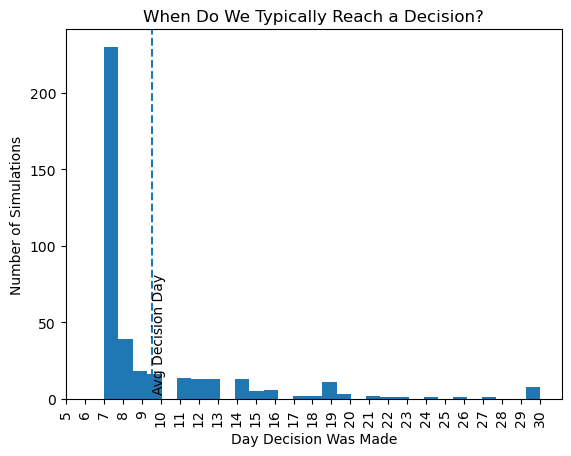

In [7]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(sim_df["decision_day"], bins=max_days)

plt.xlabel("Day Decision Was Made")
plt.ylabel("Number of Simulations")
plt.title("When Do We Typically Reach a Decision?")

plt.axvline(sim_df["decision_day"].mean(), linestyle='--')
plt.text(sim_df["decision_day"].mean(), 5, "Avg Decision Day", rotation=90)
plt.xticks(range(5, max_days + 1))
plt.xticks(range(5, max_days + 1), rotation=90)
plt.show()

# adding additional stuff

In [8]:
def run_single_experiment():

    # ====== PARAMETERS ======
    mde = 0.01  # minimum meaningful lift (1%)

    daily_volume = daily_apps_A + daily_apps_B
    value_per_conversion = 8000  # business value per booking
    max_acceptable_loss_dollars = 8000

    min_days = 7
    min_samples = 1000

    prob_threshold = 0.95
    loss_threshold = 0.001  # used for statistical fallback if needed

    samples = 20000

    # ====== 1. Initialize cumulative data ======
    cum_apps_A = 0
    cum_apps_B = 0
    cum_book_A = 0
    cum_book_B = 0

    # ====== 2. Loop through each day ======
    for day in range(1, max_days + 1):

        # ====== 3. Simulate daily outcomes ======
        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        # ====== 4. Update cumulative totals ======
        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        # ====== 5. Posterior update (Beta closed-form) ======
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        # ====== 6. Sample from posterior ======
        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        # ====== 7. Core metrics ======
        prob_B_better = np.mean(p_B > p_A)

        lift = p_B - p_A
        prob_meaningful = np.mean(lift > mde)

        # ====== 8. Expected loss ======
        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))
        expected_loss = min(loss_if_A, loss_if_B)

        # Convert to business terms

        remaining_days = max_days - day

        expected_loss_dollars = (
            expected_loss
            * daily_volume
            * value_per_conversion
            * remaining_days
        )

        # ====== 9. CI LIFT ======
        lift = p_B - p_A

        ci_lower = np.percentile(lift, 2.5)
        ci_upper = np.percentile(lift, 97.5)
        mean_lift = np.mean(lift)

        # ====== 10. DECISION LOGIC ======

        # --- Guardrails ---
        if day < min_days or cum_apps_A < min_samples:
            decision = "WAIT"

        else:
            # --- 3-Way Decision Framework ---
            if (
                prob_meaningful > 0.80
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "SHIP_B"

            elif (
                prob_B_better < (1 - prob_threshold)
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            else:
                decision = "CONTINUE"

        # ====== 11. STOPPING CONDITION ======
        if decision in ["SHIP_B", "KEEP_A"]:
            return {
                "decision_day": day,
                "decision": decision,
                "cum_apps_A": cum_apps_A,
                "cum_apps_B": cum_apps_B,
                "prob_B_better": prob_B_better,
                "prob_meaningful": prob_meaningful,
                "expected_loss_$": expected_loss_dollars,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "mean_lift": mean_lift
            }

    # ====== 12. Fallback (no decision) ======
    return {
        "decision_day": max_days,
        "decision": "INCONCLUSIVE",
        "cum_apps_A": cum_apps_A,
        "cum_apps_B": cum_apps_B,
        "prob_B_better": prob_B_better,
        "prob_meaningful": prob_meaningful,
        "expected_loss_$": expected_loss_dollars,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "mean_lift": mean_lift
    }

In [9]:
run_single_experiment()

{'decision_day': 11,
 'decision': 'SHIP_B',
 'cum_apps_A': 4400,
 'cum_apps_B': 4400,
 'prob_B_better': np.float64(0.98595),
 'prob_meaningful': np.float64(0.85655),
 'expected_loss_$': np.float64(5297.283938714037),
 'ci_lower': np.float64(0.0021161197142829783),
 'ci_upper': np.float64(0.03648886629621862),
 'mean_lift': np.float64(0.0193014863395544)}

In [10]:
results = []

for _ in range(num_simulations):
    results.append(run_single_experiment())

sim_df = pd.DataFrame(results)

In [11]:
sim_df.head()

,decision_day,decision,cum_apps_A,cum_apps_B,prob_B_better,prob_meaningful,expected_loss_$,ci_lower,ci_upper,mean_lift
0,9,SHIP_B,3600,3600,0.98735,0.88625,5964.194365,0.002800,0.040848,0.021850
1,7,SHIP_B,2800,2800,0.99875,0.98470,609.740107,0.012216,0.053697,0.032911
2,8,SHIP_B,3200,3200,0.99205,0.92205,3988.150953,0.004630,0.043617,0.024272
3,11,SHIP_B,4400,4400,0.98415,0.85425,5587.550786,0.001933,0.036264,0.019170
4,10,SHIP_B,4000,4000,0.98495,0.86515,6601.593588,0.002024,0.038376,0.020239


In [12]:
sim_df['mean_lift'].mean()

np.float64(0.02302562560370457)

Text(0.02302562560370457, 5, 'Avg Lift')

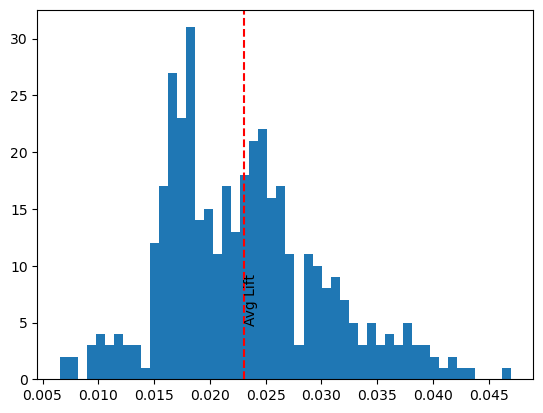

In [13]:
plt.hist(sim_df['mean_lift'], bins=50)
plt.axvline(sim_df['mean_lift'].mean(), linestyle="--", color = 'red')
plt.text(sim_df["mean_lift"].mean(), 5, "Avg Lift", rotation=90)

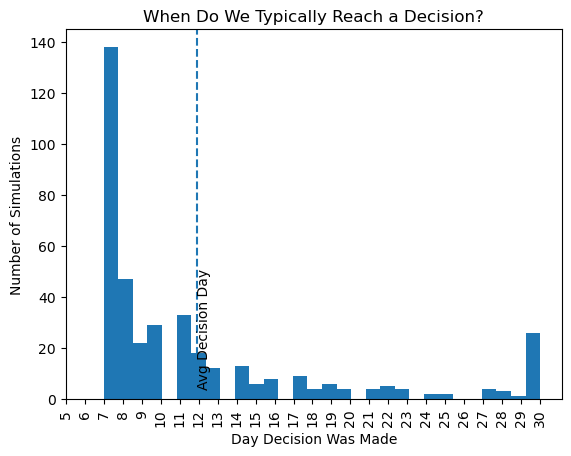

In [14]:
plt.figure()

plt.hist(sim_df["decision_day"], bins=max_days)

plt.xlabel("Day Decision Was Made")
plt.ylabel("Number of Simulations")
plt.title("When Do We Typically Reach a Decision?")

plt.axvline(sim_df["decision_day"].mean(), linestyle='--')
plt.text(sim_df["decision_day"].mean(), 5, "Avg Decision Day", rotation=90)
plt.xticks(range(5, max_days + 1))
plt.xticks(range(5, max_days + 1), rotation=90)
plt.show()

In [15]:
def run_single_experiment():

    # ====== PARAMETERS ======
    mde = 0.01  # minimum meaningful lift (1%)

    daily_volume = daily_apps_A + daily_apps_B
    value_per_conversion = 8000
    max_acceptable_loss_dollars = 8000

    min_days = 7
    min_samples = 1000

    prob_threshold = 0.95
    samples = 20000

    # ====== 1. Initialize cumulative data ======
    cum_apps_A = 0
    cum_apps_B = 0
    cum_book_A = 0
    cum_book_B = 0

    # ====== 2. Loop through each day ======
    for day in range(1, max_days + 1):

        # ====== 3. Simulate daily outcomes ======
        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        # ====== 4. Update cumulative totals ======
        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        # ====== 5. Posterior update ======
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        # ====== 6. Sample from posterior ======
        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        # ====== 7. Core metrics ======
        prob_B_better = np.mean(p_B > p_A)

        lift = p_B - p_A
        prob_meaningful = np.mean(lift > mde)

        # ====== 8. Expected loss ======
        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))
        expected_loss = min(loss_if_A, loss_if_B)

        remaining_days = max_days - day

        expected_loss_dollars = (
            expected_loss
            * daily_volume
            * value_per_conversion
            * remaining_days
        )

        # ====== 9. CI LIFT ======
        ci_lower = np.percentile(lift, 2.5)
        ci_upper = np.percentile(lift, 97.5)
        mean_lift = np.mean(lift)

        # ====== 10. DECISION LOGIC ======

        if day < min_days or cum_apps_A < min_samples:
            decision = "WAIT"

        else:

            # --- STRONG WIN ---
            if (
                prob_B_better > prob_threshold
                and ci_lower > mde
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "SHIP_B"

            # --- FUTILITY STOP (unlikely to reach MDE) ---
            elif (
                prob_meaningful < 0.10
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            # --- B is worse ---
            elif (
                prob_B_better < (1 - prob_threshold)
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            else:
                decision = "CONTINUE"

        # ====== 11. STOPPING CONDITION ======
        if decision in ["SHIP_B", "KEEP_A"]:
            return {
                "decision_day": day,
                "decision": decision,
                "cum_apps_A": cum_apps_A,
                "cum_apps_B": cum_apps_B,
                "prob_B_better": prob_B_better,
                "prob_meaningful": prob_meaningful,
                "expected_loss_$": expected_loss_dollars,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "mean_lift": mean_lift
            }

    # ====== 12. Fallback ======
    return {
        "decision_day": max_days,
        "decision": "INCONCLUSIVE",
        "cum_apps_A": cum_apps_A,
        "cum_apps_B": cum_apps_B,
        "prob_B_better": prob_B_better,
        "prob_meaningful": prob_meaningful,
        "expected_loss_$": expected_loss_dollars,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "mean_lift": mean_lift
    }

In [16]:
results = []

for _ in range(num_simulations):
    results.append(run_single_experiment())

sim_df = pd.DataFrame(results)

In [17]:
sim_df.head(100)

,decision_day,decision,cum_apps_A,cum_apps_B,prob_B_better,prob_meaningful,expected_loss_$,ci_lower,ci_upper,mean_lift
0,30,INCONCLUSIVE,12000,12000,0.99825,0.84840,0.000000,0.004976,0.025503,0.015377
1,13,SHIP_B,5200,5200,0.99970,0.97900,71.544864,0.010694,0.042175,0.026520
2,30,INCONCLUSIVE,12000,12000,0.99485,0.73950,0.000000,0.002907,0.023530,0.013316
3,8,SHIP_B,3200,3200,0.99945,0.99045,234.092711,0.013755,0.053892,0.034036
4,30,INCONCLUSIVE,12000,12000,0.99985,0.93885,0.000000,0.007848,0.028389,0.018045
...,...,...,...,...,...,...,...,...,...,...
95,30,INCONCLUSIVE,12000,12000,0.99810,0.85205,0.000000,0.005154,0.025664,0.015473
96,30,INCONCLUSIVE,12000,12000,0.96995,0.49795,0.000000,-0.000431,0.020390,0.009967
97,9,SHIP_B,3600,3600,0.99950,0.98325,105.098786,0.011710,0.049794,0.030829
98,10,SHIP_B,4000,4000,0.99935,0.98515,140.298868,0.011939,0.047458,0.029634


In [18]:
sim_df['decision'].value_counts()

decision
SHIP_B          247
INCONCLUSIVE    152
KEEP_A            1
Name: count, dtype: int64

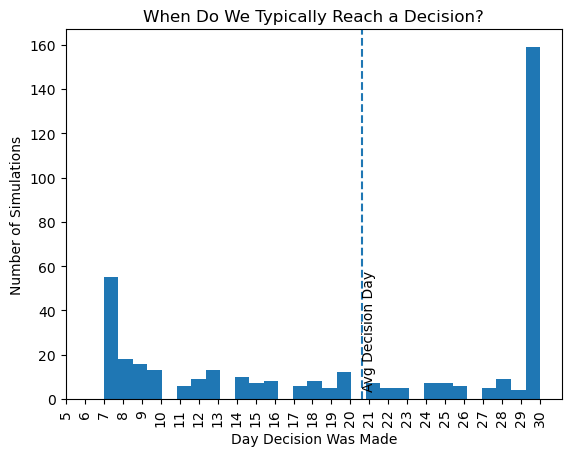

In [19]:
plt.figure()

plt.hist(sim_df["decision_day"], bins=max_days)

plt.xlabel("Day Decision Was Made")
plt.ylabel("Number of Simulations")
plt.title("When Do We Typically Reach a Decision?")

plt.axvline(sim_df["decision_day"].mean(), linestyle='--')
plt.text(sim_df["decision_day"].mean(), 5, "Avg Decision Day", rotation=90)
plt.xticks(range(5, max_days + 1))
plt.xticks(range(5, max_days + 1), rotation=90)
plt.show()

In [20]:
def run_single_experiment():

    # ====== PARAMETERS ======
    mde = 0.01

    daily_volume = daily_apps_A + daily_apps_B
    value_per_conversion = 8000
    max_acceptable_loss_dollars = 8000

    min_days = 7
    min_samples = 1000

    prob_threshold = 0.95
    samples = 20000

    # ====== 1. Initialize cumulative data ======
    cum_apps_A = 0
    cum_apps_B = 0
    cum_book_A = 0
    cum_book_B = 0

    # ====== 2. Loop through each day ======
    for day in range(1, max_days + 1):

        # ====== 3. Simulate daily outcomes ======
        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        # ====== 4. Update cumulative totals ======
        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        # ====== 5. Posterior update ======
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        # ====== 6. Sample from posterior ======
        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        # ====== 7. Core metrics ======
        prob_B_better = np.mean(p_B > p_A)

        lift = p_B - p_A
        prob_meaningful = np.mean(lift > mde)

        # ====== 8. Expected loss ======
        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))
        expected_loss = min(loss_if_A, loss_if_B)

        remaining_days = max_days - day

        expected_loss_dollars = (
            expected_loss
            * daily_volume
            * value_per_conversion
            * remaining_days
        )

        # ====== 9. Credible Interval (supporting evidence only) ======
        ci_lower = np.percentile(lift, 2.5)
        ci_upper = np.percentile(lift, 97.5)
        mean_lift = np.mean(lift)

        ci_width = ci_upper - ci_lower

        # ====== 10. DECISION LOGIC ======

        if day < min_days or cum_apps_A < min_samples:
            decision = "WAIT"

        else:

            # --- STRONG WIN ---
            if (
                prob_meaningful > 0.80
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):

                # Soft CI sanity check (optional)
                if mean_lift > 0:
                    decision = "SHIP_B"
                else:
                    decision = "CONTINUE"

            # --- FUTILITY STOP ---
            elif (
                prob_meaningful < 0.10
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            # --- CLEAR LOSS ---
            elif (
                prob_B_better < (1 - prob_threshold)
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            else:
                decision = "CONTINUE"

        # ====== 11. STOPPING CONDITION ======
        if decision in ["SHIP_B", "KEEP_A"]:
            return {
                "decision_day": day,
                "decision": decision,
                "cum_apps_A": cum_apps_A,
                "cum_apps_B": cum_apps_B,
                "prob_B_better": prob_B_better,
                "prob_meaningful": prob_meaningful,
                "expected_loss_$": expected_loss_dollars,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "ci_width": ci_width,
                "mean_lift": mean_lift
            }

    # ====== 12. Fallback ======
    return {
        "decision_day": max_days,
        "decision": "INCONCLUSIVE",
        "cum_apps_A": cum_apps_A,
        "cum_apps_B": cum_apps_B,
        "prob_B_better": prob_B_better,
        "prob_meaningful": prob_meaningful,
        "expected_loss_$": expected_loss_dollars,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_width": ci_width,
        "mean_lift": mean_lift
    }

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====== SCENARIO INPUTS ======

true_rate_A = 0.20
true_rate_B = 0.22   # expected lift

daily_apps_A = 400
daily_apps_B = 400

max_days = 30

# Decision thresholds (same as monitoring notebook)
prob_threshold = 0.95
loss_threshold = 0.001

# Simulation settings
num_simulations = 400

# ====== PARAMETERS ======
mde = 0.01

daily_volume = daily_apps_A + daily_apps_B
value_per_conversion = 8000
max_acceptable_loss_dollars = 8000

min_days = 7
min_samples = 1000

samples = 20000

np.random.seed(42)

In [22]:
def run_single_experiment():

    # ====== PARAMETERS ======
    
    cum_apps_A = 0
    cum_apps_B = 0
    cum_book_A = 0
    cum_book_B = 0

    # ====== 2. Loop through each day ======
    for day in range(1, max_days + 1):

        # ====== 3. Simulate daily outcomes ======
        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        # ====== 4. Update cumulative totals ======
        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        # ====== 5. Posterior update ======
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        # ====== 6. Sample from posterior ======
        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        # ====== 7. Core metrics ======
        prob_B_better = np.mean(p_B > p_A)

        lift = p_B - p_A
        prob_meaningful = np.mean(lift > mde)

        # ====== 8. Expected loss ======
        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))
        expected_loss = min(loss_if_A, loss_if_B)

        remaining_days = max_days - day

        expected_loss_dollars = (
            expected_loss
            * daily_volume
            * value_per_conversion
            * remaining_days
        )

        # ====== 9. Credible Interval (supporting evidence only) ======
        ci_lower = np.percentile(lift, 2.5)
        ci_upper = np.percentile(lift, 97.5)
        mean_lift = np.mean(lift)

        ci_width = ci_upper - ci_lower

        # ====== 10. DECISION LOGIC ======

        if day < min_days or cum_apps_A < min_samples:
            decision = "WAIT"

        else:

            # --- STRONG WIN ---
            if (
                prob_meaningful > 0.80
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):

                # Soft CI sanity check (optional)
                if mean_lift > 0:
                    decision = "SHIP_B"
                else:
                    decision = "CONTINUE"

            # --- FUTILITY STOP --- (not meaningful)
            elif (
                prob_meaningful < 0.10
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            # --- CLEAR LOSS --- (B worse)
            elif (
                prob_B_better < (1 - prob_threshold)
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            else:
                decision = "CONTINUE"

        # ====== 11. STOPPING CONDITION ======
        if decision in ["SHIP_B", "KEEP_A"]:
            return {
                "decision_day": day,
                "decision": decision,
                "cum_apps_A": cum_apps_A,
                "cum_apps_B": cum_apps_B,
                "prob_B_better": prob_B_better,
                "prob_meaningful": prob_meaningful,
                "expected_loss_$": expected_loss_dollars,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "ci_width": ci_width,
                "mean_lift": mean_lift
            }

    # ====== 12. Fallback ======
    return {
        "decision_day": max_days,
        "decision": "INCONCLUSIVE",
        "cum_apps_A": cum_apps_A,
        "cum_apps_B": cum_apps_B,
        "prob_B_better": prob_B_better,
        "prob_meaningful": prob_meaningful,
        "expected_loss_$": expected_loss_dollars,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_width": ci_width,
        "mean_lift": mean_lift
    }

In [23]:
results = []

for _ in range(num_simulations):
    results.append(run_single_experiment())

sim_df = pd.DataFrame(results)


decision_labels = {
    "SHIP_B": "Ship Test Feature",
    "KEEP_A": "Keep Current Experience",
    "INCONCLUSIVE": "No Decision",
    "WAIT": "Too Early"
}

sim_df["decision_label"] = sim_df["decision"].map(decision_labels)


Decision Distribution
- how often each decision occurs


In [24]:
# 1 Decision Table

decision_table = (
    sim_df
    .groupby("decision_label")
    .agg(
        simulations=("decision_day","count"),
        avg_decision_day=("decision_day","mean")
    )
    .reset_index()
)

decision_table["percent"] = (
    decision_table["simulations"]
    / decision_table["simulations"].sum()
)

decision_table["percent"] = (decision_table["percent"]*100).round(1)
decision_table["avg_decision_day"] = decision_table["avg_decision_day"].round(1)

decision_table

,decision_label,simulations,avg_decision_day,percent
0,Keep Current Experience,1,29.0,0.2
1,No Decision,31,30.0,7.8
2,Ship Test Feature,368,10.9,92.0


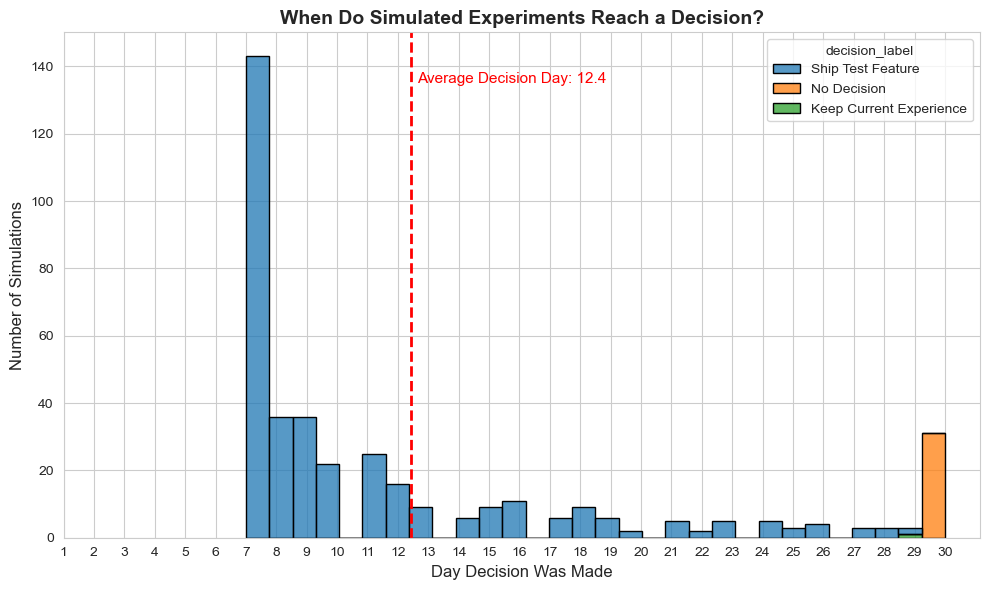

In [25]:
#2 Decision Timing

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(
    data=sim_df,
    x="decision_day",
    bins=max_days,
    edgecolor="black",
    hue="decision_label",
    multiple="stack"
)

mean_day = sim_df["decision_day"].mean()

plt.axvline(mean_day, color="red", linestyle="--", linewidth=2)

plt.text(
    mean_day + 0.2,
    plt.ylim()[1]*0.9,
    f"Average Decision Day: {mean_day:.1f}",
    color="red",
    fontsize=11
)

plt.xlabel("Day Decision Was Made", fontsize=12)
plt.ylabel("Number of Simulations", fontsize=12)

plt.title(
    "When Do Simulated Experiments Reach a Decision?",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, max_days+1))

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Day Decision Was Made')

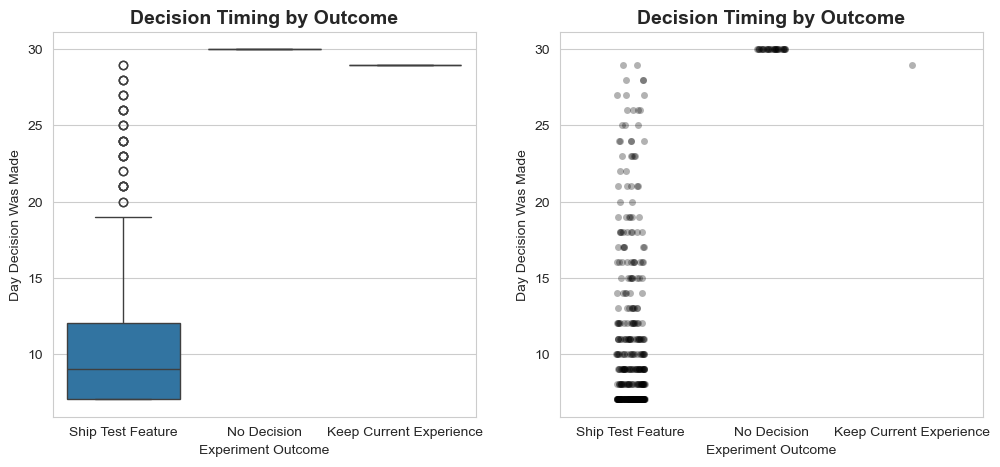

In [26]:
#3 decision timing by outcome

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="decision_label", y="decision_day", data=sim_df, ax = axes[0])
axes[0].set_title("Decision Timing by Outcome",
                fontsize=14,
                fontweight="bold")

axes[0].set_xlabel("Experiment Outcome")
axes[0].set_ylabel("Day Decision Was Made")


sns.stripplot(
    data=sim_df,
    x="decision_label",
    y="decision_day",
    color="black",
    alpha=0.3,
    jitter=True,
    ax = axes[1]
)

axes[1].set_title(
    "Decision Timing by Outcome",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Experiment Outcome")
axes[1].set_ylabel("Day Decision Was Made")


Text(0, 0.5, 'Expected Loss ($)')

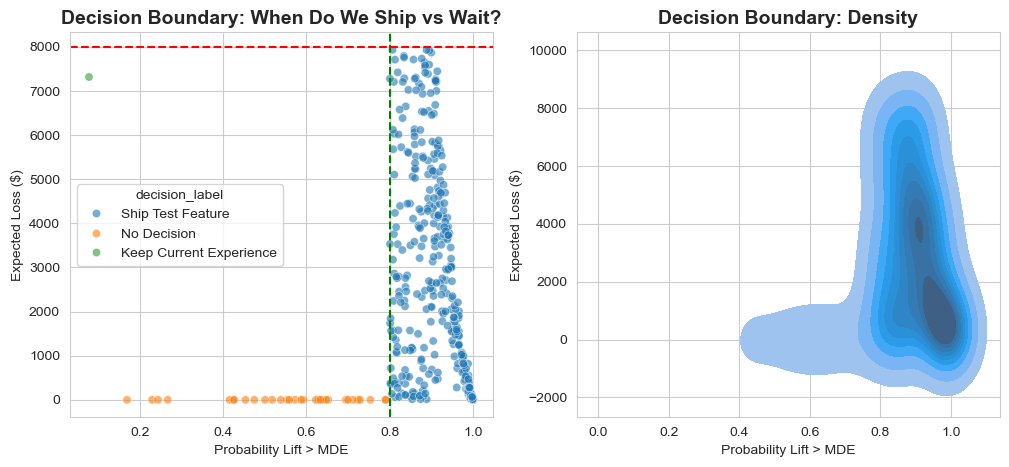

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

prob_threshold = 0.8
loss_threshold = 8000
sns.scatterplot(
    data=sim_df,
    x="prob_meaningful",
    y="expected_loss_$",
    hue="decision_label",
    alpha=0.6,
    ax = axes[0]
)
axes[0].set_title("Decision Boundary: When Do We Ship vs Wait?",
                fontsize=14,
                fontweight="bold")
axes[0].set_xlabel("Probability Lift > MDE")
axes[0].set_ylabel("Expected Loss ($)")

# Decision thresholds
axes[0].axvline(prob_threshold, linestyle="--", color="green", label="Prob Threshold")
axes[0].axhline(loss_threshold, linestyle="--", color="red", label="Loss Threshold")


sns.kdeplot(
    data=sim_df,
    x="prob_meaningful",
    y="expected_loss_$",
    #hue="decision_label",
    fill=True,
    ax = axes[1]
)
axes[1].set_title("Decision Boundary: Density",
                fontsize=14,
                fontweight="bold")

axes[1].set_xlabel("Probability Lift > MDE")
axes[1].set_ylabel("Expected Loss ($)")

Text(0, 0.5, 'Count')

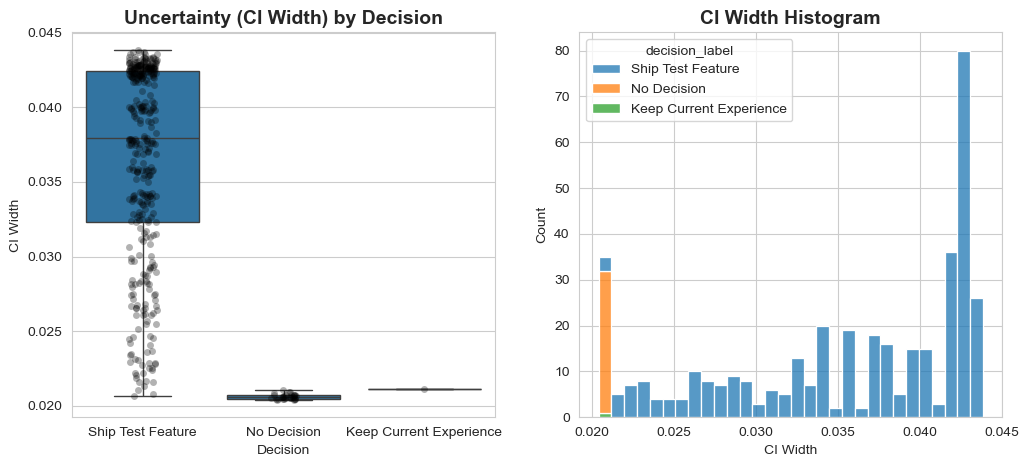

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(
    data=sim_df,
    x="decision_label",
    y="ci_width",
    ax = axes[0]
)

sns.stripplot(
    data=sim_df,
    x="decision_label",
    y="ci_width",
    color="black",
    alpha=0.3,
    jitter=True,
    ax = axes[0]
)


axes[0].set_title("Uncertainty (CI Width) by Decision",
                fontsize=14,
                fontweight="bold")
axes[0].set_xlabel("Decision")
axes[0].set_ylabel("CI Width")


sns.histplot(
    data=sim_df,
    x="ci_width",
    hue="decision_label",
    bins=30,
    multiple="stack",
    ax = axes[1]
)

axes[1].set_title("CI Width Histogram",
                fontsize=14,
                fontweight="bold")
axes[1].set_xlabel("CI Width")
axes[1].set_ylabel("Count")


In [29]:
# ====== SCENARIO INPUTS ======

true_rate_A = 0.20
true_rate_B = 0.22   # expected lift

daily_apps_A = 400
daily_apps_B = 400

max_days = 30

# Decision thresholds (same as monitoring notebook)
prob_threshold = 0.95
loss_threshold = 0.001

# Simulation settings
num_simulations = 400


# ====== PARAMETERS ======
mde = 0.01

daily_volume = daily_apps_A + daily_apps_B
value_per_conversion = 8000
max_acceptable_loss_dollars = 8000

min_days = 7
min_samples = 1000

prob_threshold = 0.95
samples = 20000

np.random.seed(42)

In [30]:
def run_single_experiment():

    # ====== 2. Loop through each day ======
    for day in range(1, max_days + 1):

        # ====== 3. Simulate daily outcomes ======
        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        # ====== 4. Update cumulative totals ======
        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        # ====== 5. Posterior update ======
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        # ====== 6. Sample from posterior ======
        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        # ====== 7. Core metrics ======
        prob_B_better = np.mean(p_B > p_A)

        lift = p_B - p_A
        prob_meaningful = np.mean(lift > mde)

        # ====== 8. Expected loss ======
        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))
        expected_loss = min(loss_if_A, loss_if_B)

        remaining_days = max_days - day

        expected_loss_dollars = (
            expected_loss
            * daily_volume
            * value_per_conversion
            * remaining_days
        )

        # ====== 9. Credible Interval (supporting evidence only) ======
        ci_lower = np.percentile(lift, 2.5)
        ci_upper = np.percentile(lift, 97.5)
        mean_lift = np.mean(lift)

        ci_width = ci_upper - ci_lower

        # ====== 10. DECISION LOGIC ======

        if day < min_days or cum_apps_A < min_samples:
            decision = "WAIT"

        else:

            # --- STRONG WIN ---
            if (
                prob_meaningful > 0.80
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):

                # Soft CI sanity check (optional)
                if mean_lift > 0:
                    decision = "SHIP_B"
                else:
                    decision = "CONTINUE"

            # --- FUTILITY STOP --- (not meaningful)
            elif (
                prob_meaningful < 0.10
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            # --- CLEAR LOSS --- (B worse)
            elif (
                prob_B_better < (1 - prob_threshold)
                and expected_loss_dollars < max_acceptable_loss_dollars
            ):
                decision = "KEEP_A"

            else:
                decision = "CONTINUE"

        # ====== 11. STOPPING CONDITION ======
        if decision in ["SHIP_B", "KEEP_A"]:
            return {
                "decision_day": day,
                "decision": decision,
                "cum_apps_A": cum_apps_A,
                "cum_apps_B": cum_apps_B,
                "prob_B_better": prob_B_better,
                "prob_meaningful": prob_meaningful,
                "expected_loss_$": expected_loss_dollars,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "ci_width": ci_width,
                "mean_lift": mean_lift
            }

    # ====== 12. Fallback ======
    return {
        "decision_day": max_days,
        "decision": "INCONCLUSIVE",
        "cum_apps_A": cum_apps_A,
        "cum_apps_B": cum_apps_B,
        "prob_B_better": prob_B_better,
        "prob_meaningful": prob_meaningful,
        "expected_loss_$": expected_loss_dollars,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_width": ci_width,
        "mean_lift": mean_lift
    }